# 09d — Chemical Filtering, Drug-Likeness, Liabilities and Diversity

## PEARL Pipeline 5

This notebook consumes the **production output of 09c** and performs chemistry-aware
triage before docking.

09c production established:

```text
1000 REINVENT4 molecules analysed
996 successfully embedded in 3D
83 molecules with a complete 5-MANDATORY pharmacophore assignment
2 strict pharmacophore-positive molecules
```

The two strict hits are retained as such, even if their physicochemical properties are poor.
In parallel, 09d creates a **near-miss rescue pool** from molecules that satisfy all mandatory
groups but fail only the optional-group requirement.

### Important methodological rule

09d does **not** relax or rewrite the 09b pharmacophore.

The two populations remain explicitly separated:

```text
STRICT_HIT
    5 mandatory + >=1 optional

NEAR_MISS_MANDATORY_ONLY
    all 5 mandatory
    optional requirement not met
```

Near-misses may be carried to docking as an exploratory rescue set, but they are never
reported as pharmacophore-positive hits.


## 1. Objectives

For strict hits and mandatory-positive near-misses, 09d computes:

- molecular weight, cLogP, TPSA, HBD/HBA, rotatable bonds;
- Lipinski and Veber rule flags;
- formal charge and ring complexity;
- fraction sp3 and QED;
- PAINS alerts;
- Brenk structural alerts;
- synthetic-accessibility score when RDKit `SA_Score` is available, otherwise an explicit
  heuristic complexity proxy;
- Morgan-fingerprint similarity and Butina diversity clustering.

The final output contains:

```text
strict pharmacophore hits
+
chemically prioritized mandatory-only rescue candidates
+
a diversity-aware docking shortlist
```

The ranking is a **triage score**, not a binding-affinity score.


In [1]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs
from rdkit.Chem import (
    AllChem,
    Crippen,
    Descriptors,
    Lipinski,
    QED,
    rdMolDescriptors,
)
from rdkit.Chem.FilterCatalog import (
    FilterCatalog,
    FilterCatalogParams,
)
from rdkit.ML.Cluster import Butina

print("RDKit chemical-filtering environment loaded.")


RDKit chemical-filtering environment loaded.


## 2. Configuration


In [2]:
OUTPUTS_ROOT = Path("outputs")

INPUT_ROOT_09C = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09c_generation"
    / "production"
)

INPUT_TABLE_DIR_09C = (
    INPUT_ROOT_09C
    / "tables"
)

RANKING_09C_PATH = (
    INPUT_TABLE_DIR_09C
    / "09c_candidate_ranking.csv"
)

POSITIVE_09C_PATH = (
    INPUT_TABLE_DIR_09C
    / "09c_pharmacophore_positive_candidates.csv"
)

QC_09C_PATH = (
    INPUT_TABLE_DIR_09C
    / "09c_QC.csv"
)

# ======================================================
# Rescue-pool definition
# ======================================================

# All mandatory-positive molecules are eligible for chemistry analysis.
# The best subset is selected later after chemical scoring and diversity.
MAX_NEAR_MISS_ANALYSIS = 81

# Number of near-miss candidates to keep before diversity selection.
TOP_NEAR_MISS_PRECLUSTER = 30

# Final exploratory rescue slots for docking.
MAX_NEAR_MISS_DOCKING = 8

# Strict pharmacophore hits are always retained in the report.
# Only chemically acceptable strict hits are automatically placed in the
# primary docking subset; poor strict hits remain as documented evidence.
MAX_STRICT_DOCKING = 10

# ======================================================
# Chemistry thresholds
# ======================================================

# Conventional oral-drug-like reference thresholds.
LIPINSKI_MW_MAX = 500.0
LIPINSKI_LOGP_MAX = 5.0
LIPINSKI_HBD_MAX = 5
LIPINSKI_HBA_MAX = 10

VEBER_TPSA_MAX = 140.0
VEBER_ROTB_MAX = 10

# Broader pre-docking envelope, intentionally less strict than Lipinski.
# Used only for triage, not to redefine the pharmacophore.
DOCKING_MW_MAX = 650.0
DOCKING_LOGP_MIN = -1.0
DOCKING_LOGP_MAX = 7.0
DOCKING_TPSA_MAX = 180.0
DOCKING_ABS_CHARGE_MAX = 2
DOCKING_ROTB_MAX = 15

# SA score: lower is easier. This threshold is a pragmatic triage cutoff.
SA_SCORE_MAX = 6.5

# Diversity clustering.
MORGAN_RADIUS = 2
MORGAN_NBITS = 2048
BUTINA_DISTANCE_CUTOFF = 0.45  # distance = 1 - Tanimoto

# ======================================================
# Output
# ======================================================

OUTPUT_ROOT = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09d_chemical_filtering"
)

TABLE_DIR = OUTPUT_ROOT / "tables"
STRUCTURE_DIR = OUTPUT_ROOT / "structures"
PLOT_DIR = OUTPUT_ROOT / "plots"
REPORT_DIR = OUTPUT_ROOT / "reports"
MODEL_DIR = OUTPUT_ROOT / "models"

for d in [
    TABLE_DIR,
    STRUCTURE_DIR,
    PLOT_DIR,
    REPORT_DIR,
    MODEL_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )

print("09c ranking:", RANKING_09C_PATH)
print("09d output:", OUTPUT_ROOT)


09c ranking: outputs/pipeline_5_pharmacophore_09c_generation/production/tables/09c_candidate_ranking.csv
09d output: outputs/pipeline_5_pharmacophore_09d_chemical_filtering


## 3. Load and validate 09c production outputs


In [3]:
required_paths = [
    RANKING_09C_PATH,
    POSITIVE_09C_PATH,
    QC_09C_PATH,
]

missing = [
    p
    for p in required_paths
    if not p.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing required 09c production outputs:\n"
        + "\n".join(str(p) for p in missing)
    )

rank09c = pd.read_csv(RANKING_09C_PATH)
positive09c = pd.read_csv(POSITIVE_09C_PATH)
qc09c = pd.read_csv(QC_09C_PATH)

qc_values = (
    qc09c["pass"]
    .astype(str)
    .str.lower()
    .map({"true": True, "false": False})
)

if qc_values.isna().any():
    qc_values = qc09c["pass"].astype(bool)

if not bool(qc_values.all()):
    raise RuntimeError(
        "09c technical QC did not pass completely."
    )

strict_df = rank09c[
    rank09c["screen_pass"] == True
].copy()

mandatory_only_df = rank09c[
    (rank09c["mandatory_match"] == True)
    & (rank09c["screen_pass"] == False)
].copy()

mandatory_only_df = mandatory_only_df.sort_values(
    "mandatory_rmsd_A",
    ascending=True,
).head(
    MAX_NEAR_MISS_ANALYSIS
).copy()

print("09c total candidates:", len(rank09c))
print("Strict pharmacophore hits:", len(strict_df))
print("Mandatory-only near-misses:", len(mandatory_only_df))

if len(strict_df) != 2:
    warnings.warn(
        f"Expected 2 strict production hits from the finalized 09c run, found {len(strict_df)}."
    )

if len(strict_df) + len(mandatory_only_df) < 2:
    raise RuntimeError(
        "No usable pharmacophore-supported population for 09d."
    )

display(
    strict_df[
        [
            "candidate_id",
            "mandatory_rmsd_A",
            "n_optional_matched",
            "optional_match_ids",
            "MW",
            "cLogP",
            "TPSA",
        ]
    ]
)


09c total candidates: 1000
Strict pharmacophore hits: 2
Mandatory-only near-misses: 81


,candidate_id,mandatory_rmsd_A,n_optional_matched,optional_match_ids,MW,cLogP,TPSA
0,MOL00570,1.561656,1,PG09,668.730,-1.8386,251.36
1,MOL00336,1.778733,1,PG07,958.298,11.3813,164.76


## 4. Build the 09d analysis population

Strict hits and near-misses are assigned immutable provenance labels.

A near-miss is **not** promoted to a strict hit by any chemistry score.


In [4]:
strict_work = strict_df.copy()
strict_work["pharmacophore_status"] = "STRICT_HIT"

near_work = mandatory_only_df.copy()
near_work["pharmacophore_status"] = "NEAR_MISS_MANDATORY_ONLY"

analysis_df = pd.concat(
    [
        strict_work,
        near_work,
    ],
    ignore_index=True,
)

analysis_df["source_09c_rank"] = analysis_df["09c_rank"]

print("09d molecules to analyse:", len(analysis_df))

display(
    analysis_df[
        [
            "candidate_id",
            "pharmacophore_status",
            "mandatory_rmsd_A",
            "n_optional_matched",
        ]
    ].head(20)
)


09d molecules to analyse: 83


,candidate_id,pharmacophore_status,mandatory_rmsd_A,n_optional_matched
0,MOL00570,STRICT_HIT,1.561656,1
1,MOL00336,STRICT_HIT,1.778733,1
2,MOL00513,NEAR_MISS_MANDATORY_ONLY,0.832790,0
3,MOL00686,NEAR_MISS_MANDATORY_ONLY,0.888151,0
4,MOL00342,NEAR_MISS_MANDATORY_ONLY,0.889731,0
5,MOL00202,NEAR_MISS_MANDATORY_ONLY,0.932058,0
6,MOL00719,NEAR_MISS_MANDATORY_ONLY,0.946764,0
7,MOL00757,NEAR_MISS_MANDATORY_ONLY,0.951182,0
8,MOL00128,NEAR_MISS_MANDATORY_ONLY,0.992449,0
9,MOL00014,NEAR_MISS_MANDATORY_ONLY,0.992882,0


## 5. PAINS and Brenk filter catalogs


In [5]:
def build_filter_catalog(catalog_enum):
    params = FilterCatalogParams()
    params.AddCatalog(catalog_enum)
    return FilterCatalog(params)

PAINS_CATALOG = build_filter_catalog(
    FilterCatalogParams.FilterCatalogs.PAINS
)

BRENK_CATALOG = build_filter_catalog(
    FilterCatalogParams.FilterCatalogs.BRENK
)

def filter_matches(catalog, mol):
    matches = catalog.GetMatches(mol)
    descriptions = []

    for match in matches:
        try:
            descriptions.append(
                match.GetDescription()
            )
        except Exception:
            descriptions.append(
                str(match)
            )

    return descriptions

print("PAINS and Brenk catalogs loaded.")


PAINS and Brenk catalogs loaded.


## 6. Synthetic accessibility score

RDKit installations commonly expose Ertl-style SA score code under `Contrib/SA_Score`.
09d uses it when available.

If unavailable, the notebook does **not** invent an SA score. It reports
`SA_method = heuristic_complexity_proxy` and uses a clearly labelled fallback based on
molecular size, rings, stereocentres, rotatable bonds and fraction sp3.


In [6]:
SA_METHOD = None
sascorer = None

try:
    from rdkit.Contrib.SA_Score import sascorer
    SA_METHOD = "RDKit_Contrib_SA_Score"
except Exception:
    try:
        import sys
        from rdkit import RDConfig

        sa_path = (
            Path(RDConfig.RDContribDir)
            / "SA_Score"
        )

        if str(sa_path) not in sys.path:
            sys.path.append(str(sa_path))

        import sascorer
        SA_METHOD = "RDKit_Contrib_SA_Score"

    except Exception:
        sascorer = None
        SA_METHOD = "heuristic_complexity_proxy"

print("SA method:", SA_METHOD)

def complexity_proxy(mol):
    heavy = mol.GetNumHeavyAtoms()
    rings = rdMolDescriptors.CalcNumRings(mol)
    rotb = Lipinski.NumRotatableBonds(mol)
    stereo = len(
        Chem.FindMolChiralCenters(
            mol,
            includeUnassigned=True,
        )
    )
    fsp3 = rdMolDescriptors.CalcFractionCSP3(mol)

    # Explicitly NOT an Ertl SA score.
    value = (
        1.0
        + 0.045 * heavy
        + 0.25 * rings
        + 0.12 * rotb
        + 0.20 * stereo
        + 0.50 * (1.0 - fsp3)
    )

    return float(
        min(10.0, max(1.0, value))
    )

def synthetic_accessibility_value(mol):
    if sascorer is not None:
        return float(
            sascorer.calculateScore(mol)
        )

    return complexity_proxy(mol)


SA method: RDKit_Contrib_SA_Score


## 7. Compute physicochemical descriptors and liabilities


In [7]:
descriptor_rows = []

invalid_ids = []

for row in analysis_df.itertuples():
    mol = Chem.MolFromSmiles(
        row.smiles
    )

    if mol is None:
        invalid_ids.append(
            row.candidate_id
        )
        continue

    mw = float(
        Descriptors.MolWt(mol)
    )

    clogp = float(
        Crippen.MolLogP(mol)
    )

    hbd = int(
        Lipinski.NumHDonors(mol)
    )

    hba = int(
        Lipinski.NumHAcceptors(mol)
    )

    tpsa = float(
        rdMolDescriptors.CalcTPSA(mol)
    )

    rotb = int(
        Lipinski.NumRotatableBonds(mol)
    )

    rings = int(
        rdMolDescriptors.CalcNumRings(mol)
    )

    aromatic_rings = int(
        rdMolDescriptors.CalcNumAromaticRings(mol)
    )

    aliphatic_rings = int(
        rdMolDescriptors.CalcNumAliphaticRings(mol)
    )

    formal_charge = int(
        Chem.GetFormalCharge(mol)
    )

    heavy_atoms = int(
        mol.GetNumHeavyAtoms()
    )

    fsp3 = float(
        rdMolDescriptors.CalcFractionCSP3(mol)
    )

    qed = float(
        QED.qed(mol)
    )

    stereocenters = len(
        Chem.FindMolChiralCenters(
            mol,
            includeUnassigned=True,
        )
    )

    pains = filter_matches(
        PAINS_CATALOG,
        mol,
    )

    brenk = filter_matches(
        BRENK_CATALOG,
        mol,
    )

    sa_value = synthetic_accessibility_value(
        mol
    )

    lipinski_violations = sum([
        mw > LIPINSKI_MW_MAX,
        clogp > LIPINSKI_LOGP_MAX,
        hbd > LIPINSKI_HBD_MAX,
        hba > LIPINSKI_HBA_MAX,
    ])

    veber_pass = (
        tpsa <= VEBER_TPSA_MAX
        and rotb <= VEBER_ROTB_MAX
    )

    broad_docking_envelope = (
        mw <= DOCKING_MW_MAX
        and DOCKING_LOGP_MIN <= clogp <= DOCKING_LOGP_MAX
        and tpsa <= DOCKING_TPSA_MAX
        and abs(formal_charge) <= DOCKING_ABS_CHARGE_MAX
        and rotb <= DOCKING_ROTB_MAX
    )

    descriptor_rows.append({
        "candidate_id": row.candidate_id,
        "canonical_smiles": Chem.MolToSmiles(
            mol,
            canonical=True,
        ),
        "MW": mw,
        "cLogP": clogp,
        "HBD": hbd,
        "HBA": hba,
        "TPSA": tpsa,
        "RotB": rotb,
        "rings": rings,
        "aromatic_rings": aromatic_rings,
        "aliphatic_rings": aliphatic_rings,
        "formal_charge": formal_charge,
        "heavy_atoms": heavy_atoms,
        "fraction_CSP3": fsp3,
        "QED": qed,
        "stereocenters": stereocenters,
        "lipinski_violations": int(
            lipinski_violations
        ),
        "lipinski_pass": (
            lipinski_violations == 0
        ),
        "veber_pass": bool(
            veber_pass
        ),
        "broad_docking_envelope": bool(
            broad_docking_envelope
        ),
        "n_PAINS": len(pains),
        "PAINS_alerts": " | ".join(pains),
        "n_Brenk": len(brenk),
        "Brenk_alerts": " | ".join(brenk),
        "SA_value": sa_value,
        "SA_method": SA_METHOD,
    })

descriptor_df = pd.DataFrame(
    descriptor_rows
)

if invalid_ids:
    print(
        "Invalid SMILES excluded:",
        invalid_ids,
    )

chem_df = analysis_df.merge(
    descriptor_df,
    on="candidate_id",
    how="inner",
    suffixes=(
        "_09c",
        "",
    ),
)

display(
    chem_df.head(20)
)

chem_df.to_csv(
    TABLE_DIR
    / "09d_all_pharmacophore_supported_chemistry.csv",
    index=False,
)


,09c_rank,candidate_id,smiles,mandatory_match,mandatory_rmsd_A,n_optional_matched,optional_match_ids,screen_pass,conf_id,MW_09c,...,lipinski_violations,lipinski_pass,veber_pass,broad_docking_envelope,n_PAINS,PAINS_alerts,n_Brenk,Brenk_alerts,SA_value,SA_method
0,1,MOL00570,CCCC=CCCCCCCCC(=O)OCC(CO)OC(=O)COC1OC(CO)C(O)C...,True,1.561656,1,PG09,True,6.0,668.730,...,3,False,False,False,0,,2,Aliphatic_long_chain | isolated_alkene,4.909325,RDKit_Contrib_SA_Score
1,2,MOL00336,COc1cnccc1-c1ccc2[nH]c(CC3=CCC4(C(COCC=O)C(=O)...,True,1.778733,1,PG07,True,4.0,958.298,...,2,False,False,False,0,,3,aldehyde | Aliphatic_long_chain | isolated_alkene,7.469069,RDKit_Contrib_SA_Score
2,3,MOL00513,COc1cc(C=NNC(=O)c2cc(NC(=O)c3ccc4c(c3)NC(c3ccc...,True,0.832790,0,NaN,False,8.0,822.746,...,3,False,False,False,1,mannich_A(296),3,imine_1 | Oxygen-nitrogen_single_bond | Thioca...,3.964448,RDKit_Contrib_SA_Score
3,4,MOL00686,C=CC(=O)NC1Cc2cc(Nc3nc(-c4cncc(C(=N)S(C)(C)C)c...,True,0.888151,0,NaN,False,5.0,476.610,...,0,True,False,True,0,,3,imine_1 | imine_2 | Michael_acceptor_1,3.950231,RDKit_Contrib_SA_Score
4,5,MOL00342,CCCCCCC(S)CN(CCCS)CCCC[N+](C)(CCCSC)CCc1ccc(CC...,True,0.889731,0,NaN,False,8.0,602.122,...,2,False,False,False,0,,3,Aliphatic_long_chain | quaternary_nitrogen_2 |...,4.121940,RDKit_Contrib_SA_Score
5,6,MOL00202,CCCCc1ccc(N=C(NN=Cc2cc(SCC(O)COc3ccc4ccccc4c3)...,True,0.932058,0,NaN,False,3.0,617.793,...,2,False,False,True,2,hzone_phenol_A(479) | thio_urea_L(1),3,imine_1 | imine_2 | Oxygen-nitrogen_single_bond,3.503202,RDKit_Contrib_SA_Score
6,7,MOL00719,CCC=CCC=CCC=CCC=CCC=CCCCC(=O)NCCOCCOCCC(=O)NCC...,True,0.946764,0,NaN,False,5.0,594.837,...,2,False,False,False,0,,2,Aliphatic_long_chain | isolated_alkene,3.171753,RDKit_Contrib_SA_Score
7,8,MOL00757,NC(=O)CCCCCCCCNc1nc2c(O)cccc2cc1C(=O)c1cc(Cl)c...,True,0.951182,0,NaN,False,6.0,469.969,...,1,False,False,True,0,,1,Aliphatic_long_chain,2.573814,RDKit_Contrib_SA_Score
8,9,MOL00128,NC(=O)c1c(NC(=O)c2cc3c(-c4ncccc4Cl)ccc(F)c3[nH...,True,0.992449,0,NaN,False,3.0,495.946,...,0,True,True,True,0,,0,,2.904212,RDKit_Contrib_SA_Score
9,10,MOL00014,CC1C=c2c(C3=CC4CCCC4c4ncccc4N3)nc(NC3CCN(C(=O)...,True,0.992882,0,NaN,False,7.0,526.689,...,1,False,True,True,0,,0,,4.717224,RDKit_Contrib_SA_Score


## 8. Chemical triage classes

The triage classification is deliberately separate from pharmacophore status.

```text
CHEM_PASS
    broad pre-docking envelope
    zero PAINS
    zero Brenk alerts
    SA <= threshold

CHEM_WARN
    broad envelope passes but one or more alert/SA criteria fail

CHEM_FAIL
    broad pre-docking envelope fails
```

A `STRICT_HIT + CHEM_FAIL` remains a strict pharmacophore hit but is not automatically
promoted to the primary docking shortlist.


In [8]:
def chemistry_class(row):
    if not bool(
        row["broad_docking_envelope"]
    ):
        return "CHEM_FAIL"

    if (
        int(row["n_PAINS"]) == 0
        and int(row["n_Brenk"]) == 0
        and float(row["SA_value"]) <= SA_SCORE_MAX
    ):
        return "CHEM_PASS"

    return "CHEM_WARN"

chem_df[
    "chemistry_class"
] = chem_df.apply(
    chemistry_class,
    axis=1,
)

class_order = pd.CategoricalDtype(
    [
        "CHEM_PASS",
        "CHEM_WARN",
        "CHEM_FAIL",
    ],
    ordered=True,
)

chem_df[
    "chemistry_class"
] = chem_df[
    "chemistry_class"
].astype(
    class_order
)

display(
    chem_df[
        [
            "candidate_id",
            "pharmacophore_status",
            "mandatory_rmsd_A",
            "chemistry_class",
            "MW",
            "cLogP",
            "TPSA",
            "RotB",
            "QED",
            "n_PAINS",
            "n_Brenk",
            "SA_value",
        ]
    ].sort_values(
        [
            "pharmacophore_status",
            "chemistry_class",
            "mandatory_rmsd_A",
        ]
    )
)


,candidate_id,pharmacophore_status,mandatory_rmsd_A,chemistry_class,MW,cLogP,TPSA,RotB,QED,n_PAINS,n_Brenk,SA_value
8,MOL00128,NEAR_MISS_MANDATORY_ONLY,0.992449,CHEM_PASS,495.946,3.66590,121.93,7,0.360911,0,0,2.904212
9,MOL00014,NEAR_MISS_MANDATORY_ONLY,0.992882,CHEM_PASS,526.689,2.72800,107.10,5,0.474684,0,0,4.717224
10,MOL00431,NEAR_MISS_MANDATORY_ONLY,0.993792,CHEM_PASS,525.576,6.30980,103.70,10,0.225140,0,0,3.043241
12,MOL00925,NEAR_MISS_MANDATORY_ONLY,1.073409,CHEM_PASS,556.564,5.36850,86.38,7,0.297989,0,0,3.448313
15,MOL00533,NEAR_MISS_MANDATORY_ONLY,1.109765,CHEM_PASS,456.590,5.79814,73.47,6,0.438983,0,0,1.941742
...,...,...,...,...,...,...,...,...,...,...,...,...
51,MOL00349,NEAR_MISS_MANDATORY_ONLY,1.505554,CHEM_FAIL,473.596,-1.09430,170.93,13,0.224410,0,0,3.392766
58,MOL00904,NEAR_MISS_MANDATORY_ONLY,1.642464,CHEM_FAIL,701.918,3.43938,131.76,11,0.273189,1,1,5.508859
65,MOL00392,NEAR_MISS_MANDATORY_ONLY,1.695748,CHEM_FAIL,545.827,7.03450,134.76,26,0.078356,0,2,3.807762
0,MOL00570,STRICT_HIT,1.561656,CHEM_FAIL,668.730,-1.83860,251.36,21,0.038006,0,2,4.909325


## 9. Descriptive chemistry-priority score

The score is used only to sort candidates *within their existing pharmacophore class*.

It rewards:

- QED;
- low Lipinski violation count;
- broad docking-envelope compliance;
- absence of PAINS/Brenk alerts;
- lower SA score;
- lower mandatory pharmacophore RMSD.

It never converts a near-miss into a strict pharmacophore hit.


In [9]:
def normalized_sa_goodness(sa_value):
    # 1 is favorable, 0 unfavorable.
    return float(
        np.clip(
            (10.0 - float(sa_value))
            / 9.0,
            0.0,
            1.0,
        )
    )

chem_df[
    "chemistry_priority_score"
] = (
    2.0
    * chem_df[
        "QED"
    ].fillna(0.0)
    + 1.0
    * chem_df[
        "broad_docking_envelope"
    ].astype(float)
    + 0.75
    * (
        chem_df[
            "n_PAINS"
        ] == 0
    ).astype(float)
    + 0.50
    * (
        chem_df[
            "n_Brenk"
        ] == 0
    ).astype(float)
    + 0.75
    * chem_df[
        "SA_value"
    ].map(
        normalized_sa_goodness
    )
    - 0.35
    * chem_df[
        "lipinski_violations"
    ].astype(float)
    - 0.20
    * chem_df[
        "mandatory_rmsd_A"
    ].astype(float)
)

chem_df = chem_df.sort_values(
    [
        "pharmacophore_status",
        "chemistry_class",
        "chemistry_priority_score",
        "mandatory_rmsd_A",
    ],
    ascending=[
        True,
        True,
        False,
        True,
    ],
).reset_index(
    drop=True
)

chem_df.to_csv(
    TABLE_DIR
    / "09d_chemistry_ranked_candidates.csv",
    index=False,
)

display(
    chem_df[
        [
            "candidate_id",
            "pharmacophore_status",
            "chemistry_class",
            "chemistry_priority_score",
            "mandatory_rmsd_A",
            "QED",
            "lipinski_violations",
            "n_PAINS",
            "n_Brenk",
            "SA_value",
        ]
    ].head(30)
)


,candidate_id,pharmacophore_status,chemistry_class,chemistry_priority_score,mandatory_rmsd_A,QED,lipinski_violations,n_PAINS,n_Brenk,SA_value
0,MOL00053,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,4.365954,1.356111,0.873832,0,0,0,2.325860
1,MOL00484,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,4.341909,1.652652,0.908861,0,0,0,2.743403
2,MOL00273,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3.926745,1.923718,0.709842,0,0,0,2.298337
3,MOL00600,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3.902629,1.211674,0.681462,0,0,0,3.615521
4,MOL00294,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3.842241,1.150579,0.591823,0,0,0,2.335469
5,MOL00857,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3.814210,1.494548,0.646702,0,0,0,3.163396
6,MOL00583,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3.781209,1.340579,0.571230,0,0,0,2.117619
7,MOL00489,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3.755615,1.578156,0.609506,0,0,0,2.773198
8,MOL00810,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3.691629,1.476422,0.542569,0,0,0,2.178710
9,MOL00464,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3.628187,1.773355,0.584235,0,0,0,3.227338


## 10. Morgan fingerprints and Tanimoto similarity


In [10]:
fp_rows = []

fps = {}

for row in chem_df.itertuples():
    mol = Chem.MolFromSmiles(
        row.canonical_smiles
    )

    if mol is None:
        continue

    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(
        mol,
        radius=MORGAN_RADIUS,
        nBits=MORGAN_NBITS,
    )

    fps[
        row.candidate_id
    ] = fp

candidate_ids = list(
    fps.keys()
)

similarity_matrix = np.eye(
    len(candidate_ids),
    dtype=float,
)

for i in range(
    len(candidate_ids)
):
    for j in range(
        i + 1,
        len(candidate_ids),
    ):
        sim = float(
            DataStructs.TanimotoSimilarity(
                fps[
                    candidate_ids[i]
                ],
                fps[
                    candidate_ids[j]
                ],
            )
        )

        similarity_matrix[
            i,
            j,
        ] = sim

        similarity_matrix[
            j,
            i,
        ] = sim

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=candidate_ids,
    columns=candidate_ids,
)

similarity_df.to_csv(
    TABLE_DIR
    / "09d_tanimoto_similarity_matrix.csv"
)

if len(candidate_ids) > 1:
    upper = similarity_matrix[
        np.triu_indices(
            len(candidate_ids),
            k=1,
        )
    ]

    print(
        "Pairwise Tanimoto mean:",
        float(
            upper.mean()
        ),
    )

    print(
        "Pairwise Tanimoto max:",
        float(
            upper.max()
        ),
    )


Pairwise Tanimoto mean: 0.12403307133698623
Pairwise Tanimoto max: 0.5263157894736842


[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerator
[14:22:43] DEPRECATION WARNING: please use MorganGenerat

## 11. Butina diversity clustering

Clustering is performed on the full 09d pharmacophore-supported population using Morgan
fingerprint Tanimoto distance.

Cluster membership is used only to avoid selecting many near-identical near-misses.


In [11]:
def butina_cluster(
    ids,
    fp_dict,
    distance_cutoff,
):
    if len(ids) == 0:
        return []

    if len(ids) == 1:
        return [
            (0,)
        ]

    dists = []

    for i in range(
        1,
        len(ids),
    ):
        sims = DataStructs.BulkTanimotoSimilarity(
            fp_dict[
                ids[i]
            ],
            [
                fp_dict[
                    ids[j]
                ]
                for j in range(i)
            ],
        )

        dists.extend(
            1.0 - float(x)
            for x in sims
        )

    clusters = Butina.ClusterData(
        dists,
        len(ids),
        distance_cutoff,
        isDistData=True,
    )

    return list(
        clusters
    )

clusters = butina_cluster(
    candidate_ids,
    fps,
    BUTINA_DISTANCE_CUTOFF,
)

cluster_map = {}

for cluster_id, members in enumerate(
    clusters,
    start=1,
):
    for member_index in members:
        cluster_map[
            candidate_ids[
                member_index
            ]
        ] = cluster_id

chem_df[
    "diversity_cluster"
] = chem_df[
    "candidate_id"
].map(
    cluster_map
)

print(
    "Butina clusters:",
    len(clusters),
)

display(
    chem_df[
        [
            "candidate_id",
            "pharmacophore_status",
            "chemistry_class",
            "diversity_cluster",
            "chemistry_priority_score",
        ]
    ].head(30)
)


Butina clusters: 83


,candidate_id,pharmacophore_status,chemistry_class,diversity_cluster,chemistry_priority_score
0,MOL00053,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,83,4.365954
1,MOL00484,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,82,4.341909
2,MOL00273,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,81,3.926745
3,MOL00600,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,80,3.902629
4,MOL00294,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,79,3.842241
5,MOL00857,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,78,3.814210
6,MOL00583,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,77,3.781209
7,MOL00489,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,76,3.755615
8,MOL00810,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,75,3.691629
9,MOL00464,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,74,3.628187


## 12. Strict-hit chemical assessment

The strict hits are reported separately so that poor drug-like properties cannot be hidden
by the rescue pool.


In [12]:
strict_assessed_df = chem_df[
    chem_df[
        "pharmacophore_status"
    ]
    == "STRICT_HIT"
].copy()

strict_assessed_df = strict_assessed_df.sort_values(
    [
        "chemistry_class",
        "chemistry_priority_score",
    ],
    ascending=[
        True,
        False,
    ],
)

strict_assessed_df.to_csv(
    TABLE_DIR
    / "09d_strict_hit_chemical_assessment.csv",
    index=False,
)

display(
    strict_assessed_df[
        [
            "candidate_id",
            "mandatory_rmsd_A",
            "optional_match_ids",
            "chemistry_class",
            "MW",
            "cLogP",
            "TPSA",
            "HBD",
            "HBA",
            "RotB",
            "lipinski_violations",
            "veber_pass",
            "n_PAINS",
            "n_Brenk",
            "SA_value",
            "QED",
        ]
    ]
)


,candidate_id,mandatory_rmsd_A,optional_match_ids,chemistry_class,MW,cLogP,TPSA,HBD,HBA,RotB,lipinski_violations,veber_pass,n_PAINS,n_Brenk,SA_value,QED
81,MOL00336,1.778733,PG07,CHEM_FAIL,958.298,11.3813,164.76,4,8,10,2,False,0,3,7.469069,0.087922
82,MOL00570,1.561656,PG09,CHEM_FAIL,668.730,-1.8386,251.36,8,16,21,3,False,0,2,4.909325,0.038006


## 13. Build the mandatory-only near-miss rescue pool

Near-misses are first prioritized chemically, then selected diversity-first.

The pharmacophore label remains `NEAR_MISS_MANDATORY_ONLY` throughout.


In [13]:
near_ranked_df = chem_df[
    chem_df[
        "pharmacophore_status"
    ]
    == "NEAR_MISS_MANDATORY_ONLY"
].copy()

near_ranked_df = near_ranked_df.sort_values(
    [
        "chemistry_class",
        "chemistry_priority_score",
        "mandatory_rmsd_A",
    ],
    ascending=[
        True,
        False,
        True,
    ],
).head(
    TOP_NEAR_MISS_PRECLUSTER
).copy()

near_ranked_df[
    "near_miss_rank"
] = np.arange(
    1,
    len(near_ranked_df) + 1,
)

near_ranked_df.to_csv(
    TABLE_DIR
    / "09d_near_miss_rescue_pool_ranked.csv",
    index=False,
)

display(
    near_ranked_df[
        [
            "near_miss_rank",
            "candidate_id",
            "mandatory_rmsd_A",
            "chemistry_class",
            "chemistry_priority_score",
            "QED",
            "MW",
            "cLogP",
            "TPSA",
            "n_PAINS",
            "n_Brenk",
            "SA_value",
            "diversity_cluster",
        ]
    ].head(20)
)


,near_miss_rank,candidate_id,mandatory_rmsd_A,chemistry_class,chemistry_priority_score,QED,MW,cLogP,TPSA,n_PAINS,n_Brenk,SA_value,diversity_cluster
0,1,MOL00053,1.356111,CHEM_PASS,4.365954,0.873832,316.361,1.40572,79.62,0,0,2.325860,83
1,2,MOL00484,1.652652,CHEM_PASS,4.341909,0.908861,360.845,2.46810,81.22,0,0,2.743403,82
2,3,MOL00273,1.923718,CHEM_PASS,3.926745,0.709842,348.405,3.31260,92.43,0,0,2.298337,81
3,4,MOL00600,1.211674,CHEM_PASS,3.902629,0.681462,472.594,1.62590,128.00,0,0,3.615521,80
4,5,MOL00294,1.150579,CHEM_PASS,3.842241,0.591823,451.552,3.42800,91.57,0,0,2.335469,79
5,6,MOL00857,1.494548,CHEM_PASS,3.814210,0.646702,437.431,3.14690,118.40,0,0,3.163396,78
6,7,MOL00583,1.340579,CHEM_PASS,3.781209,0.571230,405.458,4.05634,105.24,0,0,2.117619,77
7,8,MOL00489,1.578156,CHEM_PASS,3.755615,0.609506,407.905,4.01230,92.93,0,0,2.773198,76
8,9,MOL00810,1.476422,CHEM_PASS,3.691629,0.542569,433.556,3.13270,71.42,0,0,2.178710,75
9,10,MOL00464,1.773355,CHEM_PASS,3.628187,0.584235,387.520,3.13944,70.95,0,0,3.227338,74


## 14. Diversity-aware docking shortlist

Primary logic:

1. retain strict hits as documented strict evidence;
2. automatically promote strict hits to docking only when they are not `CHEM_FAIL`;
3. fill exploratory rescue slots with the best chemically prioritized near-misses;
4. prefer one representative per diversity cluster before taking a second member.

The resulting shortlist preserves a `docking_track` column:

```text
STRICT_PHARMACOPHORE
NEAR_MISS_RESCUE
```


In [14]:
strict_docking = strict_assessed_df[
    strict_assessed_df[
        "chemistry_class"
    ].astype(str)
    != "CHEM_FAIL"
].head(
    MAX_STRICT_DOCKING
).copy()

strict_docking[
    "docking_track"
] = "STRICT_PHARMACOPHORE"

selected_near_rows = []

seen_clusters = set()

# Pass 1: one candidate per cluster.
for _, row in near_ranked_df.iterrows():
    if len(
        selected_near_rows
    ) >= MAX_NEAR_MISS_DOCKING:
        break

    cluster = row[
        "diversity_cluster"
    ]

    if cluster in seen_clusters:
        continue

    selected_near_rows.append(
        row
    )

    seen_clusters.add(
        cluster
    )

# Pass 2: fill remaining slots by rank.
if len(
    selected_near_rows
) < MAX_NEAR_MISS_DOCKING:
    selected_ids = {
        row[
            "candidate_id"
        ]
        for row in selected_near_rows
    }

    for _, row in near_ranked_df.iterrows():
        if len(
            selected_near_rows
        ) >= MAX_NEAR_MISS_DOCKING:
            break

        if row[
            "candidate_id"
        ] in selected_ids:
            continue

        selected_near_rows.append(
            row
        )

        selected_ids.add(
            row[
                "candidate_id"
            ]
        )

if selected_near_rows:
    near_docking = pd.DataFrame(
        selected_near_rows
    )
else:
    near_docking = near_ranked_df.head(
        0
    ).copy()

near_docking[
    "docking_track"
] = "NEAR_MISS_RESCUE"

docking_shortlist_df = pd.concat(
    [
        strict_docking,
        near_docking,
    ],
    ignore_index=True,
)

docking_shortlist_df.insert(
    0,
    "09d_docking_rank",
    np.arange(
        1,
        len(docking_shortlist_df) + 1,
    ),
)

docking_shortlist_df.to_csv(
    TABLE_DIR
    / "09d_docking_shortlist.csv",
    index=False,
)

print(
    "Strict hits chemically eligible for primary docking:",
    len(strict_docking),
)

print(
    "Near-miss rescue candidates selected:",
    len(near_docking),
)

print(
    "Total 09d docking shortlist:",
    len(docking_shortlist_df),
)

display(
    docking_shortlist_df[
        [
            "09d_docking_rank",
            "candidate_id",
            "docking_track",
            "pharmacophore_status",
            "mandatory_rmsd_A",
            "chemistry_class",
            "chemistry_priority_score",
            "diversity_cluster",
        ]
    ]
)


Strict hits chemically eligible for primary docking: 0
Near-miss rescue candidates selected: 8
Total 09d docking shortlist: 8


,09d_docking_rank,candidate_id,docking_track,pharmacophore_status,mandatory_rmsd_A,chemistry_class,chemistry_priority_score,diversity_cluster
0,1,MOL00053,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,1.356111,CHEM_PASS,4.365954,83
1,2,MOL00484,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,1.652652,CHEM_PASS,4.341909,82
2,3,MOL00273,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,1.923718,CHEM_PASS,3.926745,81
3,4,MOL00600,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,1.211674,CHEM_PASS,3.902629,80
4,5,MOL00294,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,1.150579,CHEM_PASS,3.842241,79
5,6,MOL00857,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,1.494548,CHEM_PASS,3.814210,78
6,7,MOL00583,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,1.340579,CHEM_PASS,3.781209,77
7,8,MOL00489,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,1.578156,CHEM_PASS,3.755615,76


## 15. Export docking-shortlist JSON

The JSON records provenance explicitly so that downstream notebooks cannot confuse rescue
near-misses with strict pharmacophore hits.


In [15]:
def json_clean(value):
    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        if np.isnan(value):
            return None
        return float(value)

    if isinstance(value, np.bool_):
        return bool(value)

    if pd.isna(value):
        return None

    return value

payload = {
    "model": "PEARL_09d_chemical_filtering_and_diversity",
    "source": {
        "09c_mode": "production",
        "strict_pharmacophore_hits_in_09c": int(
            len(strict_df)
        ),
        "mandatory_only_near_misses_analysed": int(
            len(mandatory_only_df)
        ),
    },
    "policy": {
        "pharmacophore_not_relaxed": True,
        "strict_hit_definition": (
            "all mandatory groups plus >=1 optional group"
        ),
        "near_miss_definition": (
            "all mandatory groups but zero optional groups"
        ),
    },
    "shortlist": [
        {
            key: json_clean(value)
            for key, value in record.items()
        }
        for record in docking_shortlist_df.astype(
            object
        ).to_dict(
            orient="records"
        )
    ],
}

json_path = (
    MODEL_DIR
    / "09d_docking_shortlist.json"
)

json_path.write_text(
    json.dumps(
        payload,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "JSON:",
    json_path,
)


JSON: outputs/pipeline_5_pharmacophore_09d_chemical_filtering/models/09d_docking_shortlist.json


## 16. Export shortlist SDF with generated 3D conformers

These conformers are ligand starting geometries for downstream docking.

They are **not** claimed to be the bound pose. DiffDock/09e will determine receptor-relative
poses.


In [16]:
sdf_path = (
    STRUCTURE_DIR
    / "09d_docking_shortlist_3D.sdf"
)

writer = Chem.SDWriter(
    str(sdf_path)
)

export_rows = []

for idx, row in docking_shortlist_df.iterrows():
    mol = Chem.MolFromSmiles(
        row[
            "canonical_smiles"
        ]
    )

    if mol is None:
        export_rows.append({
            "candidate_id": row["candidate_id"],
            "sdf_exported": False,
            "reason": "invalid_smiles",
        })
        continue

    mol = Chem.AddHs(
        mol
    )

    params = AllChem.ETKDGv3()
    params.randomSeed = int(
        20260817 + idx
    )

    conf_id = AllChem.EmbedMolecule(
        mol,
        params,
    )

    if conf_id < 0:
        export_rows.append({
            "candidate_id": row["candidate_id"],
            "sdf_exported": False,
            "reason": "embed_failed",
        })
        continue

    try:
        if AllChem.MMFFHasAllMoleculeParams(
            mol
        ):
            AllChem.MMFFOptimizeMolecule(
                mol,
                confId=int(conf_id),
                maxIters=200,
            )
        elif AllChem.UFFHasAllMoleculeParams(
            mol
        ):
            AllChem.UFFOptimizeMolecule(
                mol,
                confId=int(conf_id),
                maxIters=200,
            )
    except Exception:
        pass

    mol.SetProp(
        "_Name",
        str(
            row[
                "candidate_id"
            ]
        ),
    )

    for field in [
        "docking_track",
        "pharmacophore_status",
        "chemistry_class",
    ]:
        mol.SetProp(
            field,
            str(
                row[
                    field
                ]
            ),
        )

    mol.SetProp(
        "mandatory_rmsd_A",
        str(
            row[
                "mandatory_rmsd_A"
            ]
        ),
    )

    mol.SetProp(
        "canonical_smiles",
        str(
            row[
                "canonical_smiles"
            ]
        ),
    )

    writer.write(
        mol,
        confId=int(conf_id),
    )

    export_rows.append({
        "candidate_id": row["candidate_id"],
        "sdf_exported": True,
        "reason": "",
    })

writer.close()

sdf_qc_df = pd.DataFrame(
    export_rows
)

sdf_qc_df.to_csv(
    TABLE_DIR
    / "09d_SDF_export_QC.csv",
    index=False,
)

print(
    "SDF structures exported:",
    int(
        sdf_qc_df[
            "sdf_exported"
        ].sum()
    ),
    "/",
    len(sdf_qc_df),
)

print(
    "SDF:",
    sdf_path,
)


SDF structures exported: 8 / 8
SDF: outputs/pipeline_5_pharmacophore_09d_chemical_filtering/structures/09d_docking_shortlist_3D.sdf


## 17. Diagnostic plots


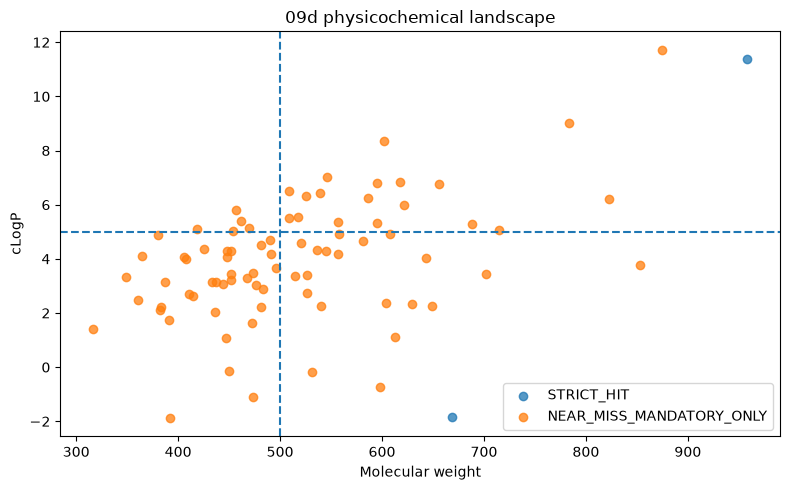

Saved: outputs/pipeline_5_pharmacophore_09d_chemical_filtering/plots/09d_MW_vs_cLogP.png


In [17]:
plot_df = chem_df.copy()

plt.figure(
    figsize=(8, 5)
)

for status in [
    "STRICT_HIT",
    "NEAR_MISS_MANDATORY_ONLY",
]:
    sub = plot_df[
        plot_df[
            "pharmacophore_status"
        ]
        == status
    ]

    if sub.empty:
        continue

    plt.scatter(
        sub[
            "MW"
        ],
        sub[
            "cLogP"
        ],
        label=status,
        alpha=0.75,
    )

plt.axvline(
    LIPINSKI_MW_MAX,
    linestyle="--",
)

plt.axhline(
    LIPINSKI_LOGP_MAX,
    linestyle="--",
)

plt.xlabel(
    "Molecular weight"
)

plt.ylabel(
    "cLogP"
)

plt.title(
    "09d physicochemical landscape"
)

plt.legend()

plt.tight_layout()

path = (
    PLOT_DIR
    / "09d_MW_vs_cLogP.png"
)

plt.savefig(
    path,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)


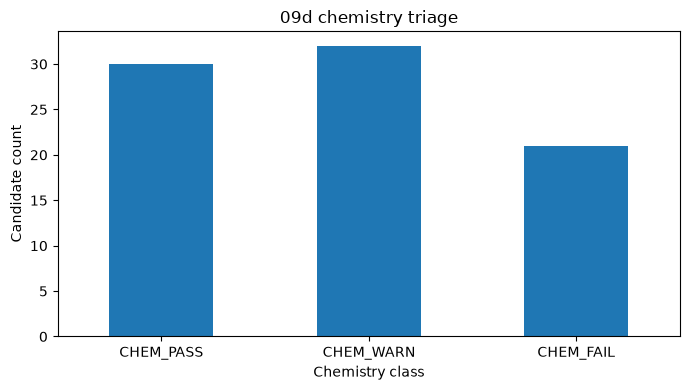

Saved: outputs/pipeline_5_pharmacophore_09d_chemical_filtering/plots/09d_chemistry_class_counts.png


In [18]:
class_counts = (
    chem_df[
        "chemistry_class"
    ]
    .astype(str)
    .value_counts()
    .reindex(
        [
            "CHEM_PASS",
            "CHEM_WARN",
            "CHEM_FAIL",
        ],
        fill_value=0,
    )
)

ax = class_counts.plot(
    kind="bar",
    figsize=(7, 4),
)

ax.set_xlabel(
    "Chemistry class"
)

ax.set_ylabel(
    "Candidate count"
)

ax.set_title(
    "09d chemistry triage"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

path = (
    PLOT_DIR
    / "09d_chemistry_class_counts.png"
)

plt.savefig(
    path,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)


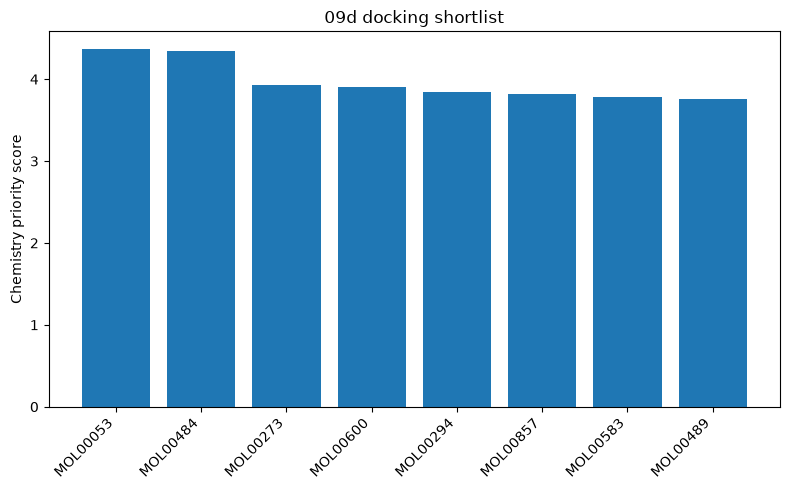

Saved: outputs/pipeline_5_pharmacophore_09d_chemical_filtering/plots/09d_docking_shortlist_scores.png


In [19]:
if len(
    docking_shortlist_df
):
    plt.figure(
        figsize=(8, 5)
    )

    x = np.arange(
        len(
            docking_shortlist_df
        )
    )

    plt.bar(
        x,
        docking_shortlist_df[
            "chemistry_priority_score"
        ],
    )

    plt.xticks(
        x,
        docking_shortlist_df[
            "candidate_id"
        ],
        rotation=45,
        ha="right",
    )

    plt.ylabel(
        "Chemistry priority score"
    )

    plt.title(
        "09d docking shortlist"
    )

    plt.tight_layout()

    path = (
        PLOT_DIR
        / "09d_docking_shortlist_scores.png"
    )

    plt.savefig(
        path,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        path,
    )


## 18. Quality control

QC verifies traceability rather than forcing a positive chemistry result.

A scientifically valid outcome may be:

```text
strict pharmacophore hits exist
but both are chemistry failures
while near-miss rescue molecules provide the only docking-ready structures
```

That result must be preserved rather than hidden.


In [20]:
strict_ids_09c = set(
    strict_df[
        "candidate_id"
    ].astype(str)
)

strict_ids_09d = set(
    strict_assessed_df[
        "candidate_id"
    ].astype(str)
)

near_ids = set(
    near_ranked_df[
        "candidate_id"
    ].astype(str)
)

shortlist_strict_ids = set(
    docking_shortlist_df.loc[
        docking_shortlist_df[
            "docking_track"
        ]
        == "STRICT_PHARMACOPHORE",
        "candidate_id",
    ].astype(str)
)

shortlist_near_ids = set(
    docking_shortlist_df.loc[
        docking_shortlist_df[
            "docking_track"
        ]
        == "NEAR_MISS_RESCUE",
        "candidate_id",
    ].astype(str)
)

qc_rows = [
    {
        "check": "09c_QC_passed",
        "pass": bool(
            qc_values.all()
        ),
    },
    {
        "check": "strict_hit_identity_preserved",
        "pass": (
            strict_ids_09c
            == strict_ids_09d
        ),
    },
    {
        "check": "strict_and_near_miss_disjoint",
        "pass": (
            strict_ids_09d.isdisjoint(
                near_ids
            )
        ),
    },
    {
        "check": "no_near_miss_promoted_to_strict",
        "pass": (
            shortlist_near_ids.isdisjoint(
                strict_ids_09d
            )
        ),
    },
    {
        "check": "chemistry_descriptors_nonempty",
        "pass": (
            len(
                chem_df
            )
            > 0
        ),
    },
    {
        "check": "diversity_clusters_created",
        "pass": (
            chem_df[
                "diversity_cluster"
            ].notna().all()
        ),
    },
    {
        "check": "docking_shortlist_nonempty",
        "pass": (
            len(
                docking_shortlist_df
            )
            > 0
        ),
    },
    {
        "check": "SDF_export_nonempty",
        "pass": (
            int(
                sdf_qc_df[
                    "sdf_exported"
                ].sum()
            )
            > 0
        ),
    },
    {
        "check": "JSON_export_created",
        "pass": (
            json_path.exists()
        ),
    },
]

qc_df = pd.DataFrame(
    qc_rows
)

ALL_QC_PASSED = bool(
    qc_df[
        "pass"
    ].all()
)

display(
    qc_df
)

print(
    "ALL QC PASSED:",
    ALL_QC_PASSED,
)

qc_df.to_csv(
    TABLE_DIR
    / "09d_QC.csv",
    index=False,
)


,check,pass
0,09c_QC_passed,True
1,strict_hit_identity_preserved,True
2,strict_and_near_miss_disjoint,True
3,no_near_miss_promoted_to_strict,True
4,chemistry_descriptors_nonempty,True
5,diversity_clusters_created,True
6,docking_shortlist_nonempty,True
7,SDF_export_nonempty,True
8,JSON_export_created,True


ALL QC PASSED: True


## 19. Automatic report


In [21]:
strict_chem_counts = (
    strict_assessed_df[
        "chemistry_class"
    ]
    .astype(str)
    .value_counts()
    .to_dict()
)

report_lines = [
    "# 09d — Chemical Filtering, Drug-Likeness, Liabilities and Diversity",
    "",
    "## Input",
    f"- 09c production candidates: {len(rank09c)}",
    f"- Strict pharmacophore hits: {len(strict_df)}",
    f"- Mandatory-only near-misses analysed: {len(mandatory_only_df)}",
    "",
    "## Strict-hit chemistry",
    (
        "- Strict chemistry classes: "
        + ", ".join(
            f"{k}={v}"
            for k, v in strict_chem_counts.items()
        )
    ),
    "",
]

for row in strict_assessed_df.itertuples():
    report_lines.append(
        (
            f"- {row.candidate_id} | {row.chemistry_class} | "
            f"MW={row.MW:.1f} | cLogP={row.cLogP:.2f} | "
            f"TPSA={row.TPSA:.1f} | HBD={row.HBD} | HBA={row.HBA} | "
            f"RotB={row.RotB} | Lipinski violations={row.lipinski_violations} | "
            f"PAINS={row.n_PAINS} | Brenk={row.n_Brenk} | "
            f"SA={row.SA_value:.2f} ({row.SA_method})"
        )
    )

report_lines.extend([
    "",
    "## Diversity and rescue",
    f"- Total Butina clusters: {len(clusters)}",
    f"- Ranked near-miss rescue pool: {len(near_ranked_df)}",
    f"- Near-miss rescue candidates selected for docking: {len(near_docking)}",
    f"- Strict hits chemically eligible for primary docking: {len(strict_docking)}",
    f"- Total docking shortlist: {len(docking_shortlist_df)}",
    "",
    "## Docking shortlist",
])

for row in docking_shortlist_df.itertuples():
    report_lines.append(
        (
            f"- {row.candidate_id} | {row.docking_track} | "
            f"{row.pharmacophore_status} | {row.chemistry_class} | "
            f"mandatory RMSD={row.mandatory_rmsd_A:.3f} Å | "
            f"chemistry score={row.chemistry_priority_score:.3f} | "
            f"cluster={row.diversity_cluster}"
        )
    )

report_lines.extend([
    "",
    "## Interpretation",
    (
        "09d keeps pharmacophore evidence and chemical tractability as separate axes. "
        "A chemically poor strict pharmacophore hit remains a strict hit, but is not "
        "automatically treated as a desirable drug-like lead."
    ),
    (
        "Mandatory-only near-misses are retained as an explicitly labelled exploratory "
        "rescue track for docking; they do not satisfy the complete 09b screening rule."
    ),
    (
        "PAINS/Brenk alerts and synthetic-accessibility metrics are heuristic triage "
        "signals, not experimental toxicity or synthesis measurements."
    ),
    (
        "The 09d shortlist is intended for 09e docking. Docking outcomes must still be "
        "interpreted alongside pharmacophore provenance and chemistry class."
    ),
    "",
    f"ALL QC PASSED: {ALL_QC_PASSED}",
])

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR
    / "09d_chemical_filtering_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(
    report_text
)

print(
    "\nReport:",
    report_path.resolve(),
)


# 09d — Chemical Filtering, Drug-Likeness, Liabilities and Diversity

## Input
- 09c production candidates: 1000
- Strict pharmacophore hits: 2
- Mandatory-only near-misses analysed: 81

## Strict-hit chemistry
- Strict chemistry classes: CHEM_FAIL=2

- MOL00336 | CHEM_FAIL | MW=958.3 | cLogP=11.38 | TPSA=164.8 | HBD=4 | HBA=8 | RotB=10 | Lipinski violations=2 | PAINS=0 | Brenk=3 | SA=7.47 (RDKit_Contrib_SA_Score)
- MOL00570 | CHEM_FAIL | MW=668.7 | cLogP=-1.84 | TPSA=251.4 | HBD=8 | HBA=16 | RotB=21 | Lipinski violations=3 | PAINS=0 | Brenk=2 | SA=4.91 (RDKit_Contrib_SA_Score)

## Diversity and rescue
- Total Butina clusters: 83
- Ranked near-miss rescue pool: 30
- Near-miss rescue candidates selected for docking: 8
- Strict hits chemically eligible for primary docking: 0
- Total docking shortlist: 8

## Docking shortlist
- MOL00053 | NEAR_MISS_RESCUE | NEAR_MISS_MANDATORY_ONLY | CHEM_PASS | mandatory RMSD=1.356 Å | chemistry score=4.366 | cluster=83
- MOL00484 | NEAR_MISS_RESCUE | NE

# 20. Final interpretation and next step

If `ALL QC PASSED: True`, 09d is complete.

The downstream logic is:

```text
09c strict pharmacophore hits
            +
09c mandatory-only near-misses
            ↓
09d chemistry / liabilities / diversity
            ↓
two clearly labelled tracks
            ↓
STRICT_PHARMACOPHORE
NEAR_MISS_RESCUE
            ↓
09e docking to EGFR
```

The next notebook should be:

```text
09e — EGFR docking and pose/interaction evaluation
```

09e must preserve the `docking_track` and `pharmacophore_status` columns so that a favorable
docking score cannot silently convert a near-miss rescue molecule into a strict
pharmacophore hit.
